In [1]:
import numpy as np
import networkx as nx
from scipy.ndimage import binary_dilation
import tifffile
import pandas as pd
import matplotlib.pyplot as plt
from shapely import Polygon, distance
from skimage import measure
import networkx as nx
import skimage as ski
import dask.array as da

In [ ]:
mask = tifffile.imread("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/reconcile_cyto_mask2.tif")
df = pd.read_csv("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/cells_nucleus_results2.csv", index_col="label").drop(columns=["nucleus_percent_touching_1", "nucleus_bounds"]).rename(columns={"nucleus_i":"i", "nucleus_j":"j"})

In [5]:
df = pd.read_csv("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/cells_nucleus_results2.csv", index_col="label").drop(columns=["nucleus_percent_touching_1", "nucleus_bounds"]).rename(columns={"nucleus_i":"i", "nucleus_j":"j"})
df

,nucleus_area,i,j,nucleus_intensity_mean,nucleus_intensity_max,nucleus_intensity_min,nucleus_intensity_std,nucleus_eccentricity,cells_area,cells_i,...,cells_eccentricity,foci_count,foci_area,nucleus_number_neighbors_1,nucleus_first_neighbor_distance,nucleus_second_neighbor_distance,cells_number_neighbors_1,cells_percent_touching_1,cells_first_neighbor_distance,cells_second_neighbor_distance
label,,,,,,,,,,,,,,,,,,,,,
1,1368.0,123.198099,4759.907164,1756.975877,4393.0,117.0,1100.720947,0.847415,3019.0,122.020205,...,0.695597,11,329,0,256.260952,268.101194,0,NaN,237.336710,265.981359
2,2400.0,226.157917,7277.699583,2099.292083,4961.0,192.0,860.824177,0.531190,11032.0,199.394851,...,0.510674,9,198,0,116.867906,454.181840,0,NaN,154.037252,509.653926
3,1533.0,241.376386,5038.601435,954.318330,2262.0,52.0,619.777950,0.639616,5104.0,248.857955,...,0.436122,14,395,0,88.723640,267.392903,0,NaN,81.521674,260.393462
4,1511.0,282.994044,4960.244209,1115.457313,3298.0,20.0,846.993765,0.808642,5014.0,271.511169,...,0.815749,12,276,0,88.723640,179.121750,0,NaN,81.521674,183.060952
5,3162.0,309.100569,5997.748261,7588.945604,16779.0,300.0,4897.598881,0.795601,8586.0,288.947007,...,0.649243,42,1373,0,76.286903,95.553911,1,NaN,116.775537,129.007486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,13157.0,3544.642244,3897.125105,4345.125485,11967.0,217.0,2003.165449,0.814460,105000.0,3592.191714,...,0.729133,125,2154,0,211.672642,263.551862,2,NaN,252.211706,268.398867
185,2525.0,3522.904554,1856.174653,1031.980990,2095.0,60.0,398.043643,0.831157,13103.0,3517.125315,...,0.896832,2,24,0,55.901638,148.086118,4,NaN,68.910492,139.275151
186,2460.0,3578.083740,1865.132927,1144.819512,2255.0,100.0,445.643282,0.901778,11961.0,3576.036034,...,0.864762,0,0,0,55.901638,137.030880,2,NaN,68.910492,170.687364


In [3]:
def prepare_box_for_contours(box, shape, pad=3):
    """Marginally pads a bounding box so that object boundaries
    are not on cropped image patch edges.
    """
    for i in range(2):
        box[i] = min(0, box[i] - pad)
        box[i+2] = max(shape[i], box[i] + pad)
        
    slices = tuple([slice(box[i], box[i+2]) for i in range(2)])
    top_left = np.array(box[:2])[None] # (1, 2)
    return slices, top_left

def make_polygons_from_mask(mask):
    """Constructs a polygon for each object in a mask. Returns
    a dict where each key is a label id and values are shapely polygons.
    """
    polygons = {}
    for rp in measure.regionprops(mask):
        # Faster to compute contours on small cell tiles than the whole image
        box_slices, box_top_left = prepare_box_for_contours(list(rp.bbox), mask.shape)
        label_mask = mask[box_slices] == rp.label

        label_cnts = np.concatenate(
            measure.find_contours(label_mask), axis=0
        )

        polygons[rp.label] = Polygon(label_cnts + box_top_left)
    
    return polygons

def pairwise_polygon_distance(polygons_dict):
    """Computes pairwise distance between all polygons in
    a dictionary. Returns a dictionary of distances.
    """
    distances = {l: {} for l in polygons_dict.keys()}
    for i in polygons_dict.keys():
        for j in polygons_dict.keys():
            # nested loop is slow but we cache results
            # to eliminate duplicate work
            if i != j and distances[i].get(j) is None:
                distances[i][j] = distance(polygons_dict[i], polygons_dict[j])
                
    return distances

In [4]:
polygons_dict = make_polygons_from_mask(mask)
distances_dict = pairwise_polygon_distance(polygons_dict)

In [6]:
distances = pd.DataFrame(distances_dict)
distances_flat = distances.to_numpy().flatten()
distances_flat = distances_flat[~np.isnan(distances_flat)]

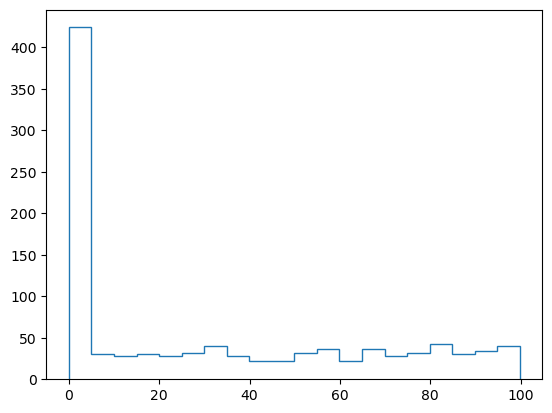

In [7]:
counts, bins = np.histogram(distances_flat[distances_flat<100], bins=20)
plt.stairs(counts, bins)

In [8]:
G = nx.Graph()

# add all cells
G.add_nodes_from(polygons_dict.keys())

threshold = 20  # adjust

for i, neighbors in distances_dict.items():
    for j, d in neighbors.items():
        if d <= threshold:
            G.add_edge(i, j)

components = list(nx.connected_components(G))

colony_map = {}
for k, comp in enumerate(components):
    for cell_id in comp:
        colony_map[cell_id] = k

df["colony_id_poly"] = df.index.map(colony_map)

sizes = df["colony_id_poly"].value_counts()

valid = sizes[sizes >= 10].index

df["in_colony"] = df["colony_id_poly"].isin(valid)

In [9]:
df[np.isnan(df["colony_id_poly"])] = -1

In [11]:
img_path = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day24_s12.ome.tif"
y0 = 4000
x0 = 10000

img = da.from_array(tifffile.imread(img_path))[:,y0:y0+4000, x0:x0+8400].compute()
# coverslip = da.from_zarr(tifffile.imread(coverslip_path, aszarr=True))[y0:y0+6400, x0:x0+6400]

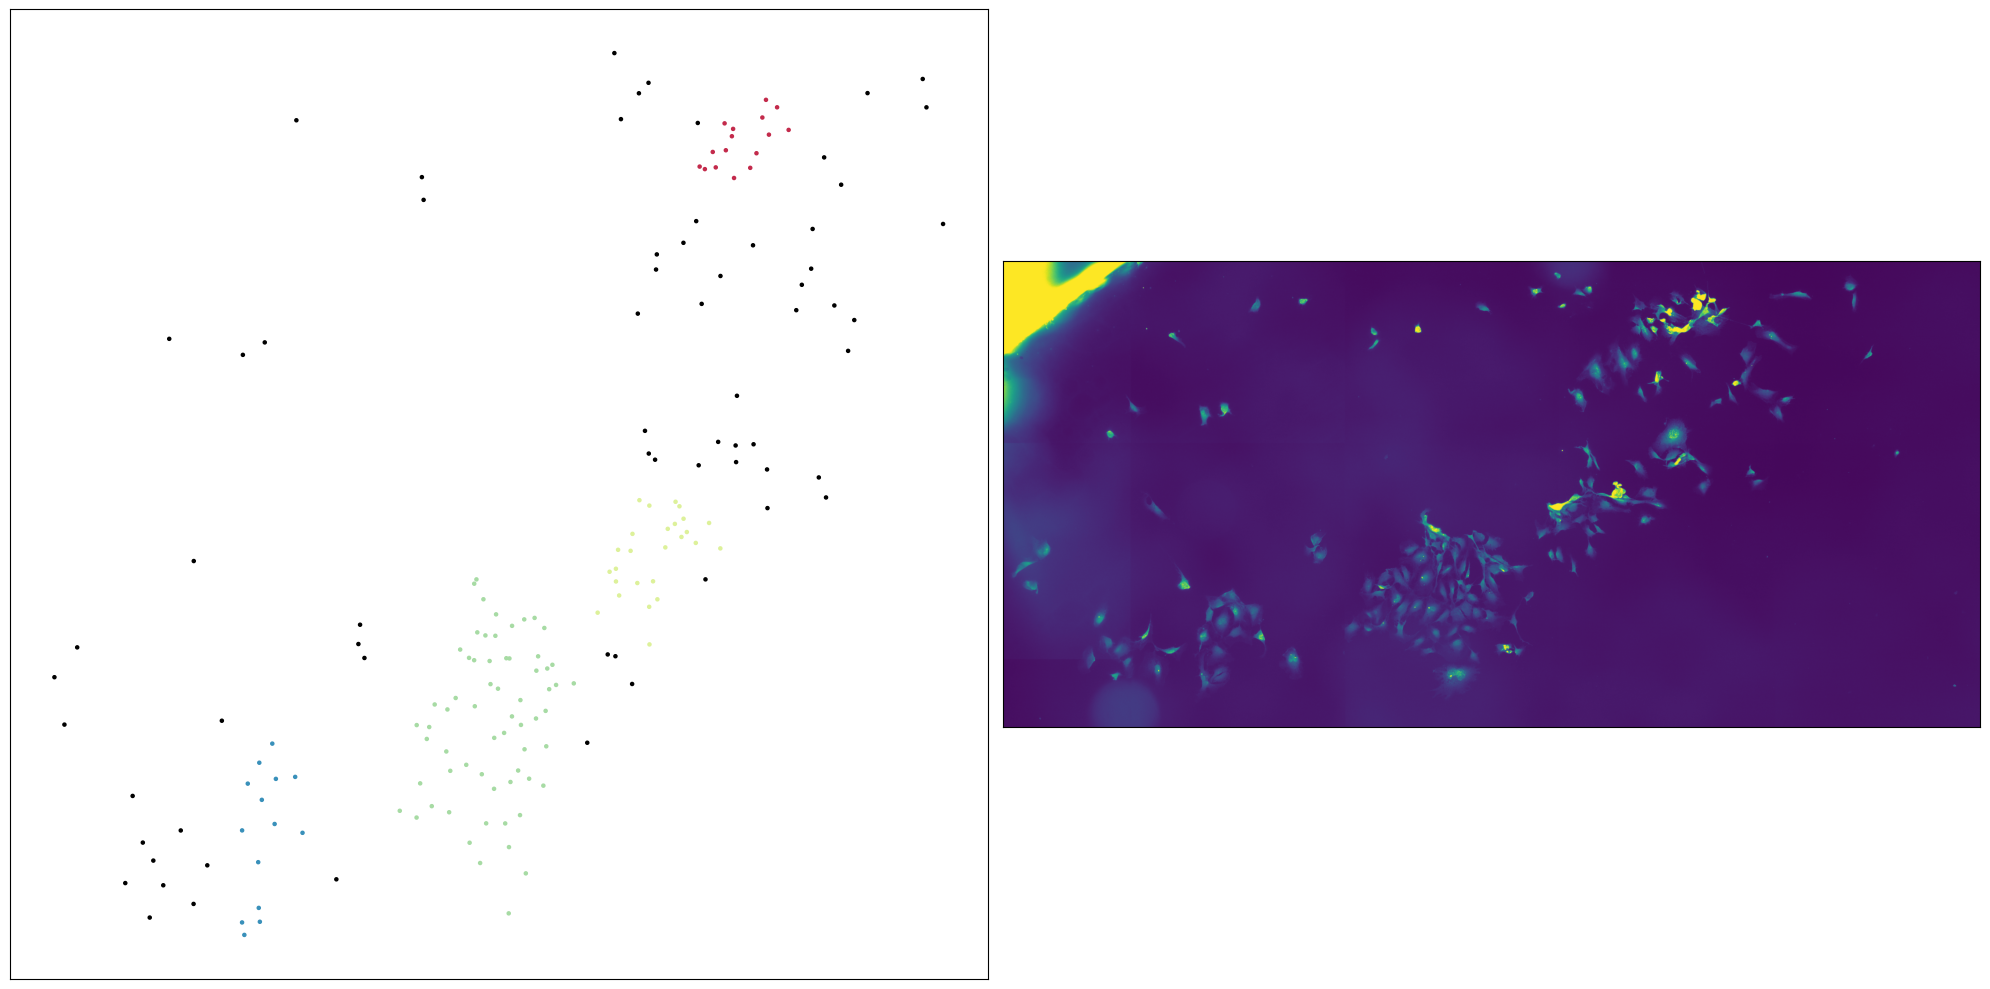

In [12]:
labels = df["colony_id_poly"].values
unique_labels = np.unique(labels)

# assign a color to each label
colors_map = {
    lab: plt.cm.Spectral(i / len(unique_labels))
    for i, lab in enumerate(unique_labels)
}

# override noise (-1) to black
filtered_dict = {key:(value if np.isin(key,valid)
          else (0, 0, 0, 1)) for key, value in colors_map.items()}

# build color list per point
colors = [filtered_dict[lab] for lab in labels]

fig, ax = plt.subplots(ncols=2,figsize=(20,10))

ax[0].scatter(
    df["j"],
    df["i"],
    c=colors,
    s=5
)

ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].invert_yaxis()

ax[1].imshow(ski.exposure.rescale_intensity(img[1], in_range=(0,3000)))
ax[1].set_xticks([])
ax[1].set_yticks([])
plt.tight_layout()
plt.show()

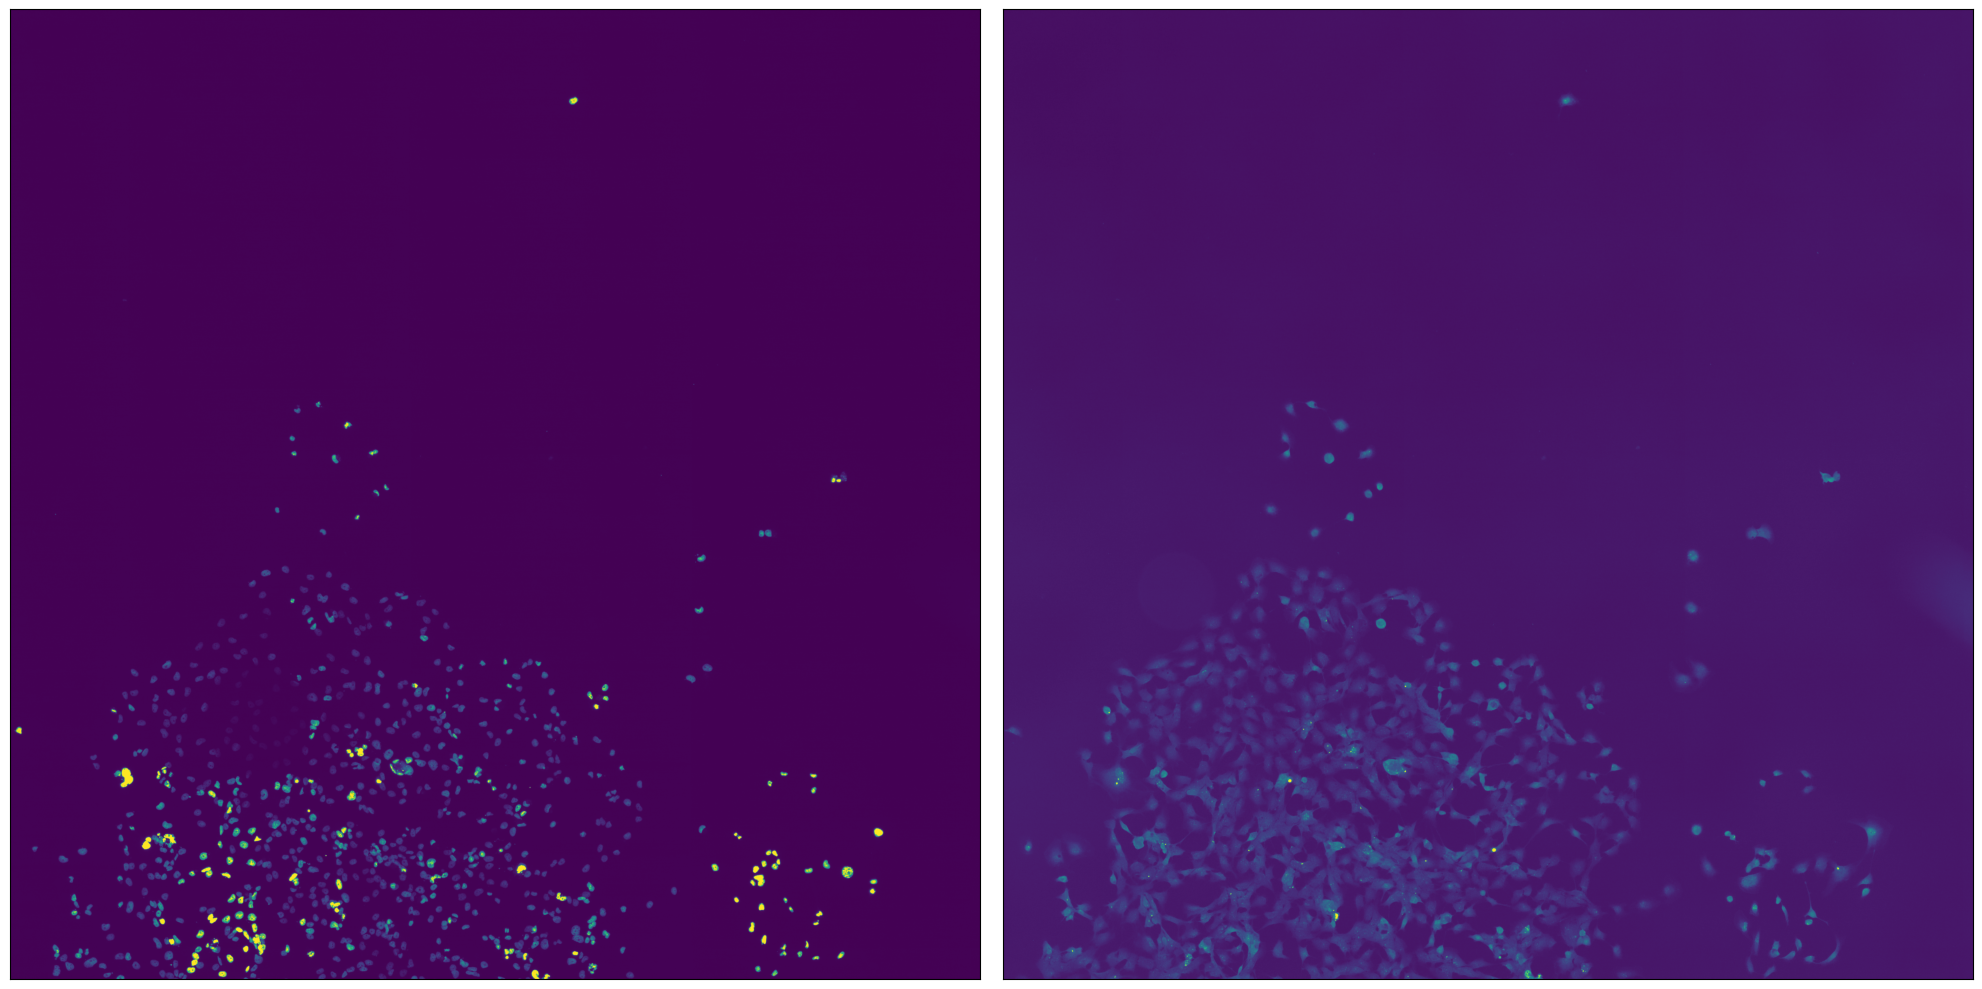

In [101]:
fig, ax = plt.subplots(ncols=2,figsize=(20,10))

for i in range(2):
    ax[i].imshow(ski.exposure.rescale_intensity(img[i], in_range=(0,3000)))
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout()
plt.show()